In [93]:
import sys

sys.path.append("../")
import numpy as np
import matplotlib.pyplot as plt

#load the necessary odometry modules
from odometry.datasets.map_handler import MapHandler
from odometry.datasets.radnav_ds import radnavDS
from odometry.test_benches.combined_pc_kalman_vel_filter_stacked_tb import combinedPCVelFilteringStackedTB
from odometry.localization.icp2D_localization import icp2DLocalization
from odometry.plotting.plotter_kalman import PlotterKalman
from odometry.plotting.movies import MovieGenerator


In [94]:
from dotenv import load_dotenv
import os

#loading enviroment variables
load_dotenv()
DATASET_PATH=os.getenv("DATASET_DIRECTORY")
MAP_DIRECTORY=os.getenv("MAP_DIRECTORY")

#setup the datasets
dataset = radnavDS(
    dataset_path=DATASET_PATH + "/WILK_vel_cfg_2",
    radar_folder="radar_combined",
    lidar_folder="lidar",
    camera_folder="camera",
    imu_orientation_folder="imu_data",
    imu_full_folder="imu_data_full",
    vehicle_vel_folder="vehicle_vel"
)

map_handler = MapHandler(
    maps_folder=MAP_DIRECTORY,
    map_file="wilkinson.yaml"
)

found 3588 radar samples
found 3588 lidar samples
found 3588 camera samples
found 3588 imu (orientation only) samples
found 3588imu (full data) samples
found 3588 vehicle velocity samples
loaded map from /data/radnav/maps/wilkinson.yaml


In [95]:
#initialize the localizers
radar_odometry = icp2DLocalization(
    icp_matching_distance_threshold=0.1,#originally 0.5
    icp_best_points_percentile=65,
    icp_convergence_translation_threshold=1e-3,
    icp_convergence_rotation_threshold=1e-4,
    icp_point_pairs_threshold=7, #originally 5
    icp_max_iterations=20,
    self_detection_radius_m=1.5 #originally 0.25
)

lidar_odometry = icp2DLocalization(
    icp_matching_distance_threshold=0.6, #originally 0.6
    icp_best_points_percentile=50,
    icp_convergence_translation_threshold=1e-3,
    icp_convergence_rotation_threshold=1e-4,
    icp_point_pairs_threshold=10,
    icp_max_iterations=20,
    self_detection_radius_m=0.25
)

loaded map with 20750 points
loaded map with 20750 points


gt icp estimated heading:-0.38331762381417633 deg, pose:[-0.17834203  0.00373634]
radar icp estimated heading:-0.8035361012032451 deg, pose:[-0.19705594 -0.19444812]


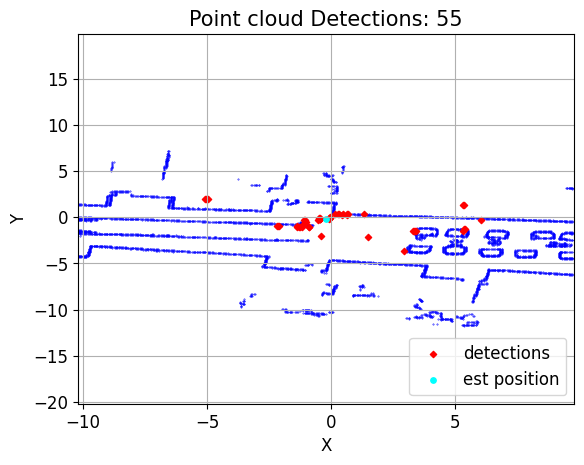

In [96]:
filter_threshold = 0.4

#initialize the test bench
test_bench = combinedPCVelFilteringStackedTB(
    localizer=radar_odometry,
    gt_localizer=lidar_odometry,
    map_handler=map_handler,
    dataset=dataset,
    vel_filter_v_thresh = filter_threshold,
    vel_filter_enabled = True,
    min_static_rejection_radius = 0.5, #was 0.5
    dynamic_cluster_eps = 1.0, #was 3
    dynamic_cluster_min_samples = 30 #was 30
)

start_heading = np.deg2rad(0)
start_pose = np.array([0.03,0.11])

new_heading_rad,new_pose_m = test_bench.init_localization(
    est_start_heading_rad=start_heading,
    est_start_pose_m=start_pose,
    show=True
)

In [97]:
#initialize the kalman filter
start_time_s = test_bench.get_dataset_start_time(idx=0)
print("dataset start time: {}s".format(start_time_s))

test_bench.init_filter(
    est_start_heading_rad=start_heading,
    est_start_position_m=start_pose,
    start_time_s=start_time_s
)

dataset start time: 1721415806.850829s


found temp dir: /home/undergrads/temp
clearing temp directory /home/undergrads/temp


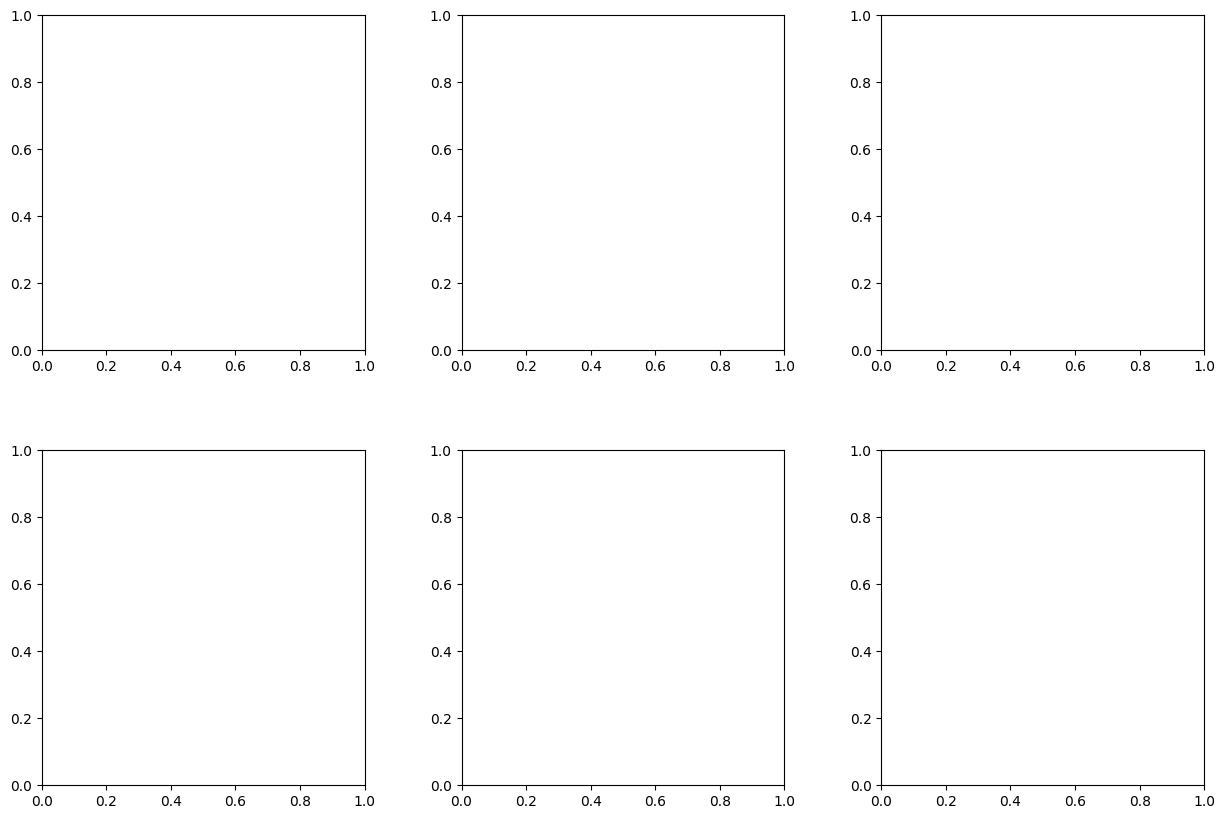

In [98]:
#loading directory from .env file
MOVIE_TEMP_DIRECTORY = os.getenv("MOVIE_TEMP_DIRECTORY")

#initialize the movie maker
movie_generator = MovieGenerator(
    temp_dir_path=MOVIE_TEMP_DIRECTORY
)
movie_generator.initialize_figure(
    nrows=2,
    ncols=3,
    figsize=(15,10)
)

In [99]:
end_idx = 250
test_bench.run(
    max_frame=end_idx,
    gt_enabled=False,
    movie_generator=None) #=movie_generator)

100%|██████████| 250/250 [00:00<00:00, 1006.21it/s]


In [100]:
movie_generator.save_movie(video_file_name="wilk_vel_data.mp4",fps=20)

0it [00:00, ?it/s]


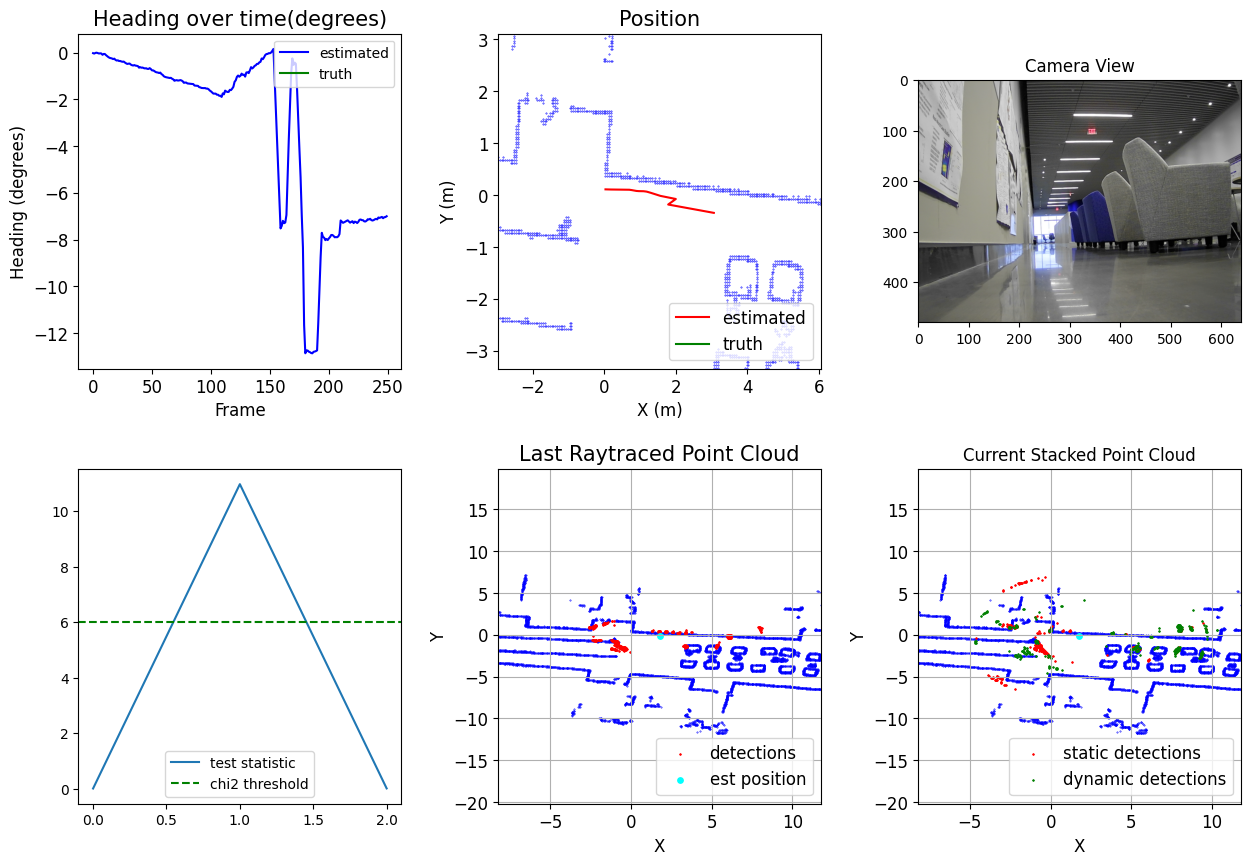

In [101]:
test_bench.plot_compilation(
    idx=end_idx-1,
    show=True
)

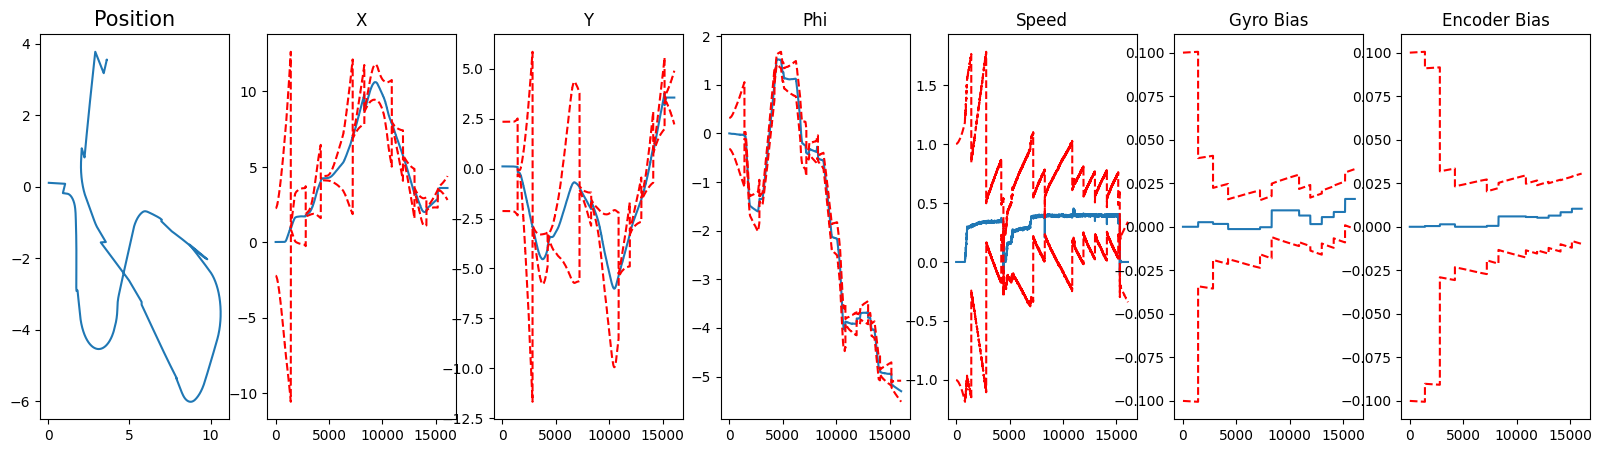

In [10]:
#plot kalman state history
kalman_plotter = PlotterKalman()

kalman_plotter.plot_kalman_result_history(
    x_history=np.array(test_bench.history_filter_est),
    p_history=np.array(test_bench.history_filter_p),
    idx=-1
)

100%|██████████| 41/41 [00:00<00:00, 297.20it/s]


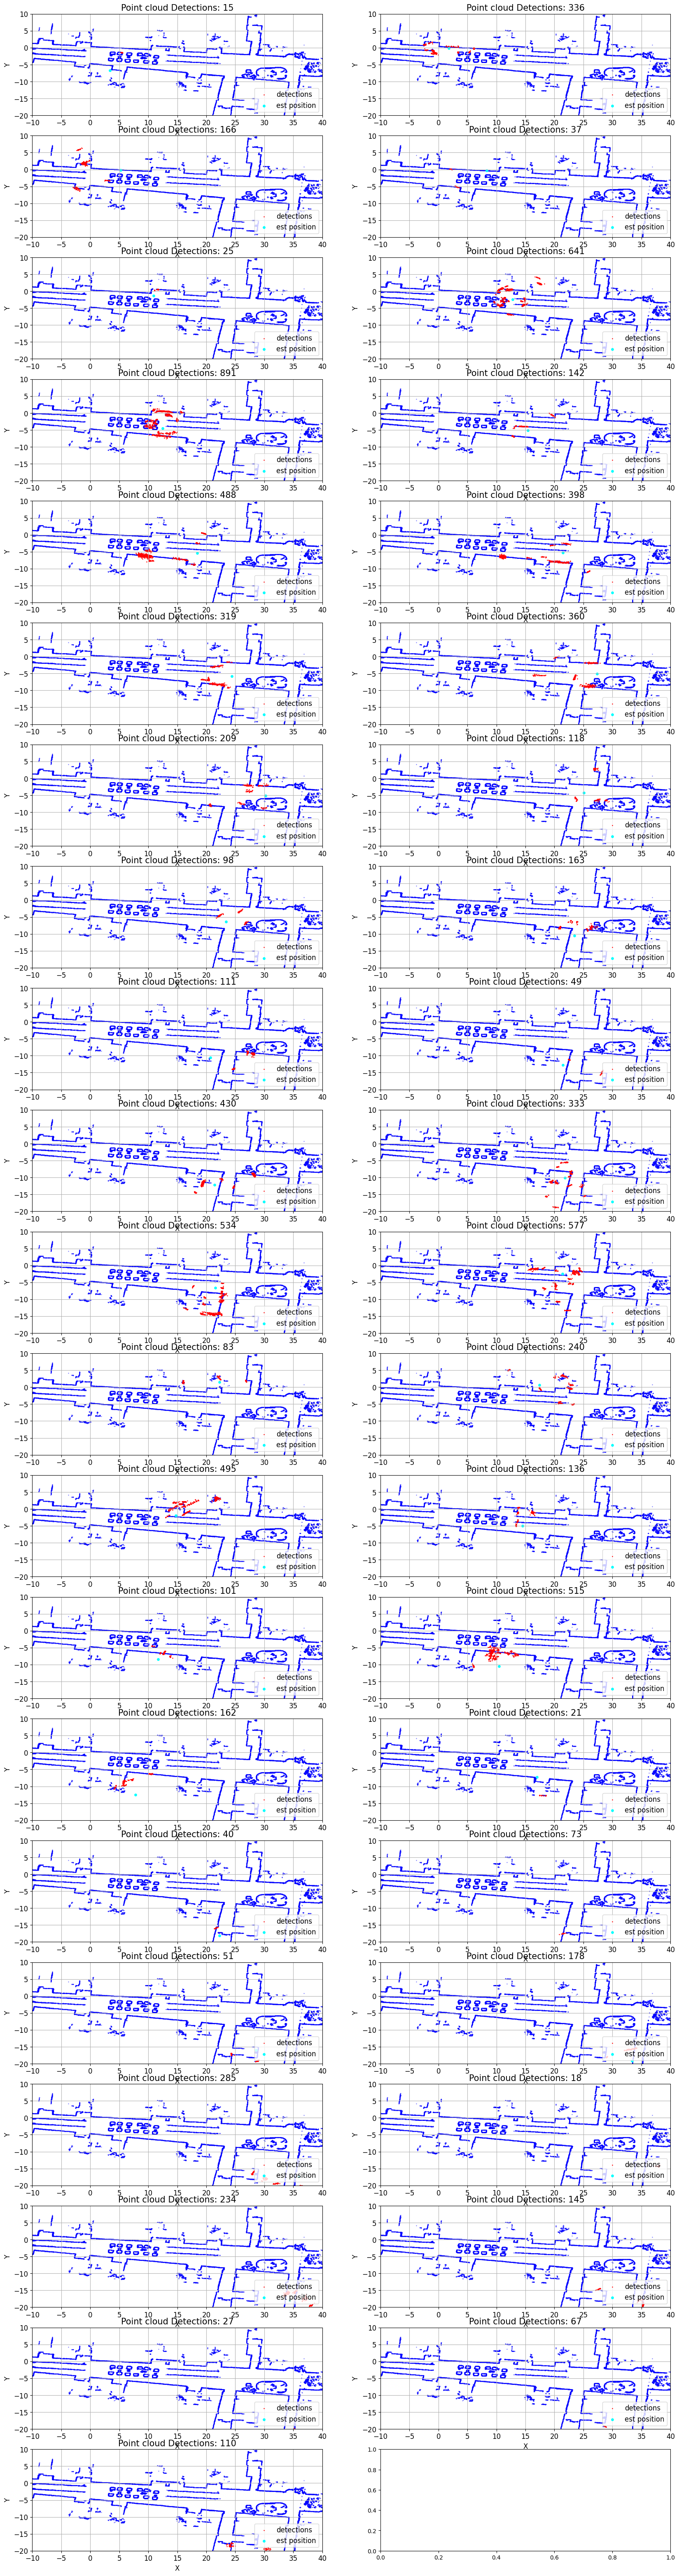

In [66]:
from tqdm import tqdm

r = 21
c = 2

fig, axs = plt.subplots(r, c, figsize = (20, 80))

rc = 0
cc = 0
test_bench.plotter_localization.marker_size=0.5
for idx in tqdm(range(len(test_bench.history_pc_stacker_point_clouds))):
    test_bench.plotter_localization.plot_detections_on_map(
        current_points=test_bench.history_pc_stacker_point_clouds[idx],
        heading_rad=test_bench.history_pc_stacker_heading_rad[idx],
        pose_m=test_bench.history_pc_stacker_position_m[idx],
        ax=axs[cc,rc],
        show=False
    )
    axs[cc,rc].set_ylim(-20,10)
    axs[cc,rc].set_xlim(-10, 40)
    rc += 1
    if(rc == c) :
        rc = 0
        cc += 1
        
fig.savefig("Images/images/wilk_2.png")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

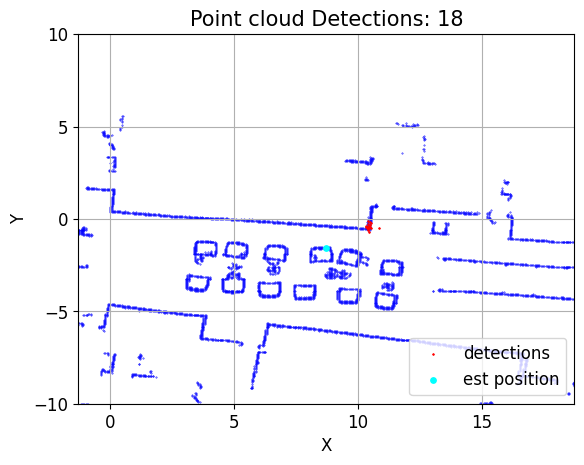

In [12]:
#plotting the saved ray traced point clouds
# plot the lidar point cloud
idx = 5
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5
test_bench.plotter_localization.plot_detections_on_map(
    current_points=test_bench.history_pc_stacker_point_clouds[idx],
    heading_rad=test_bench.history_pc_stacker_heading_rad[idx],
    pose_m=test_bench.history_pc_stacker_position_m[idx],
    ax=ax,
    show=False
)
ax.set_ylim(-10,10)
plt.show

In [13]:
test_bench.analyze()

,Metric,Euclidian,x,y,phi
0,Mean,1.872458,0.234781,-0.741378,-0.389289
1,Variance,3.484011,2.999061,3.386287,0.122903
2,Median,0.998552,-0.065169,0.035849,-0.204452
3,0.9th percentile,4.499350,3.438211,4.111241,0.846699


## Debugging (testing ray tracing)

In [14]:

from odometry.point_cloud_processing.vel_filtering import VelFiltering

if(test_bench.vel_filtering_enabled):
    detections = dataset.get_radar_detections(idx)
    ego_x_vel = dataset.get_vehicle_vel_data(idx)[0,1]
    vehicle_vel = np.array([ego_x_vel,0.0])
    
    vel_filter = VelFiltering(filter_threshold)
    
    dynamic_objects = vel_filter.get_dynamic_detections(detections,vehicle_vel)
    print(dynamic_objects)
else:
    print("Velocity Filtering Disabled")

[]


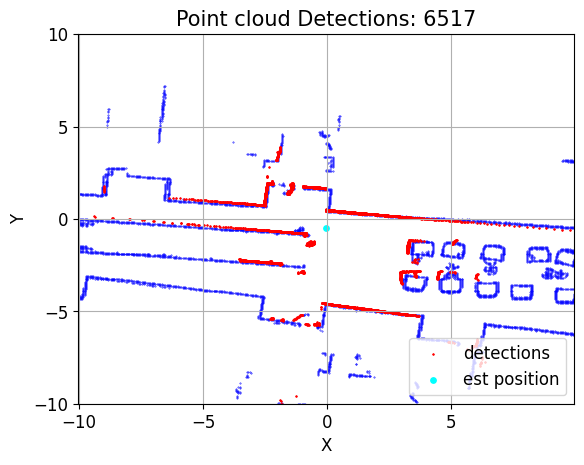

In [15]:
# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter_localization.plot_lidar_points_on_map(
    idx=end_idx-1,
    heading_rad=test_bench.gt_localizer.current_heading_rad,
    pose_m=test_bench.gt_localizer.current_pose_m,
    ax=ax,
    show=False
)
ax.set_ylim(-10,10)
plt.show()

0.4259531123170558
6.559921741485596


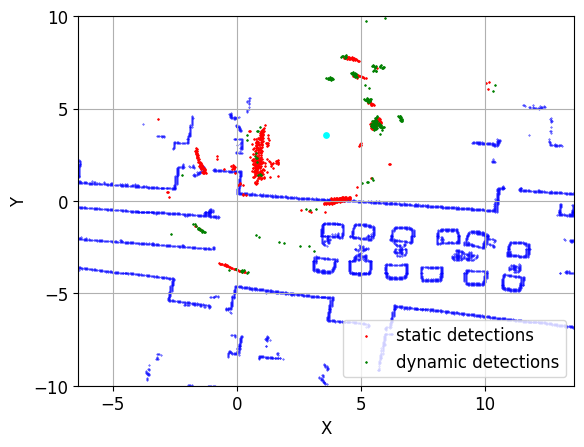

In [16]:
combined_point_cloud = test_bench.point_cloud_stacker.get_points()
dynamic_combined_point_cloud = test_bench.dynamic_point_cloud_stacker.get_points()
print(test_bench.point_cloud_stacker.get_rel_distance_m())
print(test_bench.point_cloud_stacker.get_elapsed_time())

# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5
# test_bench.plotter_localization.plot_detections_on_map(
#     current_points=combined_point_cloud,
#     heading_rad=test_bench.point_cloud_stacker.current_heading_rad,
#     pose_m=test_bench.point_cloud_stacker.current_pose_m,
#     ax=ax,
#     show=False
# )

test_bench.plotter_localization.plot_dynamic_and_static_detections_on_map(
    static_points=combined_point_cloud,
    dynamic_points = dynamic_combined_point_cloud,
    heading_rad = test_bench.point_cloud_stacker.current_heading_rad,
    pose_m= test_bench.point_cloud_stacker.current_pose_m,
    ax = ax,
    show = False
)
ax.set_ylim(-10,10)
plt.show()

static
0
1
2
3
4
5
6
dynamic
0
1
2
3
4


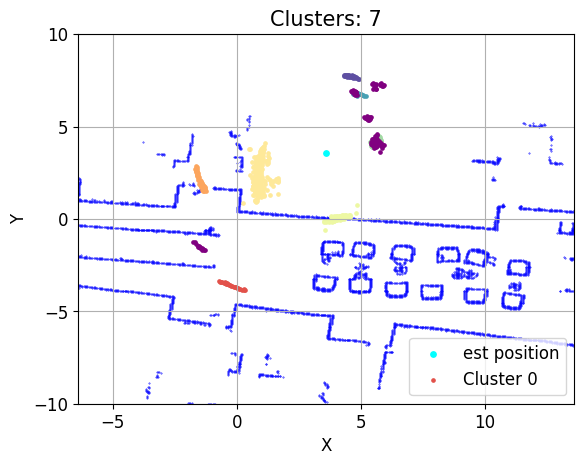

In [17]:
from odometry.point_cloud_processing.multipath import MultiPath
from odometry.supportFns import rotation_functions
from odometry.supportFns import coordinate_systems

idx=500

stacked_pc_cart = test_bench.point_cloud_stacker.get_points()
dynamic_stacked_pc_cart = test_bench.dynamic_point_cloud_stacker.get_points()

multipath = MultiPath(
    clustering_eps=0.5,
    clustering_min_samples=15
)

dynamic_multipath = MultiPath(
    clustering_eps=0.5,
    clustering_min_samples=15
)

labels = multipath._cluster_points(stacked_pc_cart)
if(np.any(dynamic_stacked_pc_cart)):
    dynamic_labels = dynamic_multipath._cluster_points(dynamic_stacked_pc_cart)

    # plot the lidar point cloud
    fig,ax = plt.subplots()
    test_bench.plotter_localization.marker_size=0.5
    test_bench.plotter_localization.plot_dynamic_and_static_detection_clusters_on_map(
        static_points=stacked_pc_cart,
        dynamic_points=dynamic_stacked_pc_cart,
        labels=labels,
        dynamic_labels=dynamic_labels,
        heading_rad=test_bench.point_cloud_stacker.current_heading_rad,
        pose_m=test_bench.point_cloud_stacker.current_pose_m,
        ax=ax,
        plot_raw_detections=False,
        show=False
    )
else:
    fig,ax = plt.subplots()
    test_bench.plotter_localization.marker_size=0.5
    test_bench.plotter_localization.plot_detection_clusters_on_map(
        current_points=stacked_pc_cart,
        labels=labels,
        heading_rad=test_bench.point_cloud_stacker.current_heading_rad,
        pose_m=test_bench.point_cloud_stacker.current_pose_m,
        ax=ax,
        plot_raw_detections=False,
        show=False
    )

ax.set_ylim(-10,10)
plt.show()

In [18]:
from tqdm import tqdm 

for i in tqdm(range(1000)):
    stacked_pc_cart = test_bench.point_cloud_stacker.get_points()
    valid_stacked_pc_cart = multipath.remove_multipath(stacked_pc_cart)

100%|██████████| 1000/1000 [00:03<00:00, 290.62it/s]


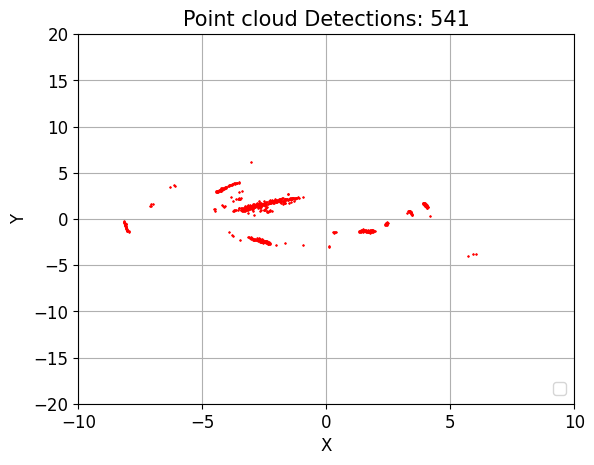

In [19]:
test_bench.plotter_localization.plot_detections(
    stacked_pc_cart,
    show=True
)

[-1  0  1  2  3  4  5  6]


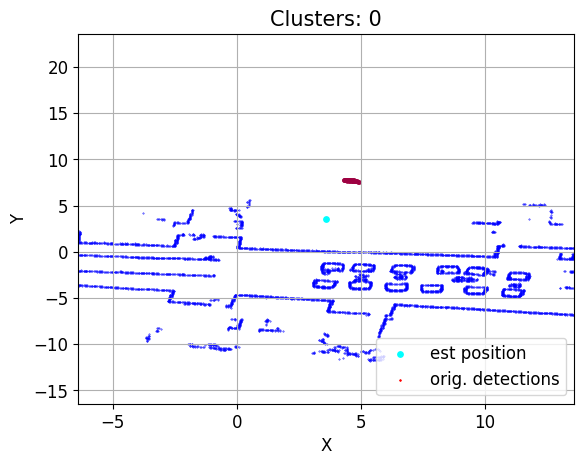

In [20]:
labels = test_bench.multipath._cluster_points(stacked_pc_cart)

print(np.unique(labels))
cluster_to_plot = 6
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5
test_bench.plotter_localization.plot_detection_clusters_on_map(
    current_points=stacked_pc_cart[labels==cluster_to_plot],
    labels=labels[labels==cluster_to_plot],
    heading_rad=test_bench.point_cloud_stacker.current_heading_rad,
    pose_m=test_bench.point_cloud_stacker.current_pose_m,
    ax=ax,
    plot_raw_detections=True,
    show=False
)

In [21]:
pc_polar = coordinate_systems.cartesian_to_polar(stacked_pc_cart)
#enable tracking for labels and valid points
unique_labels = np.unique(labels)[1:] #remove the -1 label
valid_points = np.ones(pc_polar.shape[0],dtype=bool)
#handle points already not in a cluster
valid_points[labels==-1] = 0

#for each cluster determine the range of its closest point
cluster_ranges = np.array([
    np.min(pc_polar[labels==cluster_id,0]) for \
    cluster_id in unique_labels
])

#sort the clusters by their ranges
sorted_idxs = np.argsort(cluster_ranges)


cluster_idx = 9
cluster_points = pc_polar[labels==unique_labels[cluster_idx]]

#get the maximum range and angle bounds of the cluster
angle_bounds = [np.min(cluster_points[:,1]),np.max([cluster_points[:,1]])]
max_range = np.max(cluster_points[:,0])
print("original angle bounds: {}, range: {}".format(angle_bounds,max_range))

#handle special case where points are clustered around -pi,pi
if angle_bounds[1] - angle_bounds[0] > np.pi: #assume no cluster occupies more than +pi
    #determine the correct bounds

    #set the positive bound
    angle_bounds[1] = np.min(cluster_points[cluster_points[:,1] > 0,1])
    #set the negative bound
    angle_bounds[0] = np.max(cluster_points[cluster_points[:,1] < 0,1])

    print("new angle bounds: {}, range: {}".format(angle_bounds,max_range))

    #identify indicies of points that are past these points
    invalid_idxs = \
        (pc_polar[:,0] > max_range) & \
        ((pc_polar[:,1] > angle_bounds[1]) | \
        (pc_polar[:,1] < angle_bounds[0]))
else: #standard case
    invalid_idxs = \
        (pc_polar[:,0] > max_range) & \
        (pc_polar[:,1] < angle_bounds[1]) & \
        (pc_polar[:,1] > angle_bounds[0])

valid_points[invalid_idxs] = 0

valid_stacked_pc_cart = stacked_pc_cart[valid_points,:]

test_bench.plotter_localization.plot_detections(
    valid_stacked_pc_cart,
    show=True
)


IndexError: index 9 is out of bounds for axis 0 with size 7

<function matplotlib.pyplot.show(close=None, block=None)>

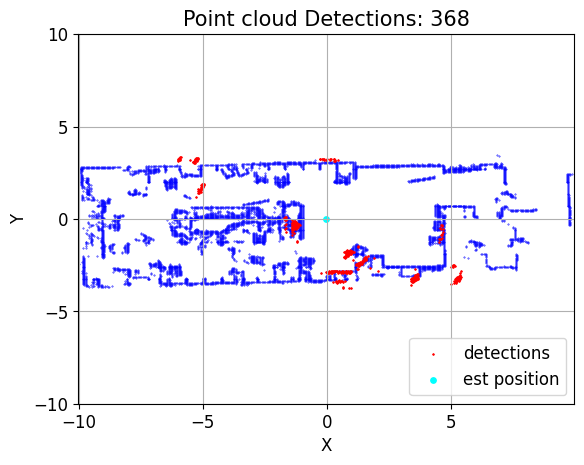

In [ ]:
#get the remaining valid points and re-cluster them
valid_stacked_pc_cart = multipath.remove_multipath(stacked_pc_cart)

# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5
test_bench.plotter_localization.plot_detections_on_map(
    current_points=valid_stacked_pc_cart,
    heading_rad=test_bench.point_cloud_stacker.current_heading_rad,
    pose_m=test_bench.point_cloud_stacker.current_pose_m,
    ax=ax,
    show=False
)
ax.set_ylim(-10,10)
plt.show

Filter estimate: heading: 2.3295967910125244 rad, pose: [-0.02107579 -0.01097126] m
New estimate: heading: 2.5061131366245144 rad, pose: [-0.22567187 -0.02466167] m
GT: heading: 2.402337022708369 rad, pose: [0.11697973 0.009803  ] m


<function matplotlib.pyplot.show(close=None, block=None)>

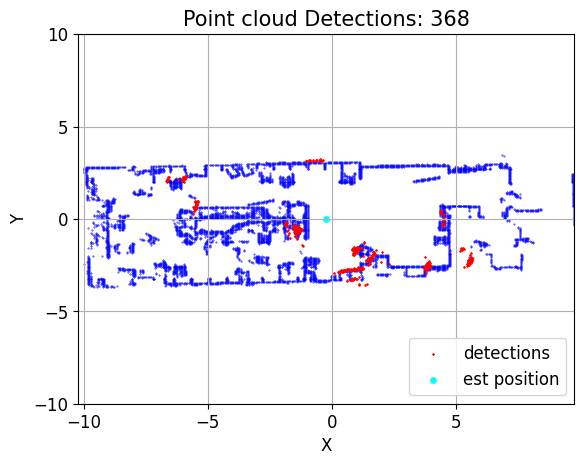

In [ ]:
#perform an ICP update
test_bench.localizer.icp_best_points_percentile = 95
est_heading_rad,est_pose_m = test_bench.localizer.update_odometry(
    points=valid_stacked_pc_cart,
    estimated_heading_rad=test_bench.filter.x[2],
    estimated_pose_m=np.array(
        [test_bench.filter.x[0],
         test_bench.filter.x[1]])
)

print("Filter estimate: heading: {} rad, pose: {} m".format(
    test_bench.filter.x[2],
    np.array(
        [test_bench.filter.x[0],
         test_bench.filter.x[1]])
))
print("New estimate: heading: {} rad, pose: {} m".format(
    est_heading_rad,est_pose_m
))
print("GT: heading: {} rad, pose: {} m".format(
    test_bench.gt_localizer.current_heading_rad,
    test_bench.gt_localizer.current_pose_m
))

# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5
test_bench.plotter_localization.plot_detections_on_map(
    current_points=valid_stacked_pc_cart,
    heading_rad=est_heading_rad,
    pose_m=est_pose_m,
    ax=ax,
    show=False
)
ax.set_ylim(-10,10)
plt.show